In [16]:
import sys
sys.path.append('..')
import phd_ms
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

In [17]:

#Change this line to the directory where inputs are stored
INPUT_FILE= '/home/pbeamer/Documents/h5ad/graphst/adata_151673_gst_0.h5ad'

#adata key of embedding for spatial clustering and of ground truth labels
EMBEDDING = 'X_gst'
GROUND_TRUTH = 'cluster'

#Set the scale parameters we want to use, and keys to save
RESOLUTIONS = np.linspace(start=0.15,stop=.95,num=8)
RES_KEYS = [f'leiden_{r:.3f}' for r in RESOLUTIONS]



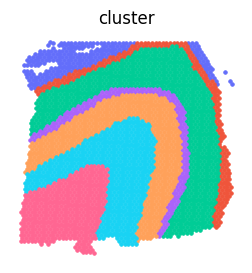

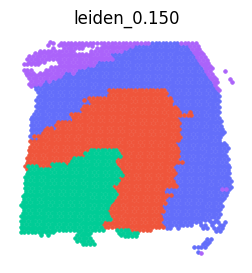

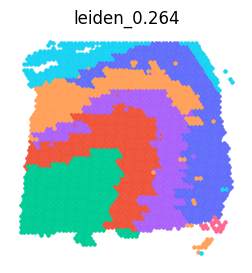

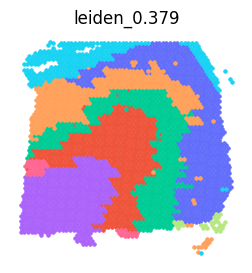

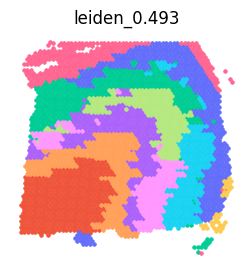

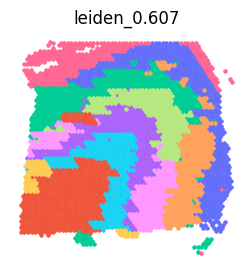

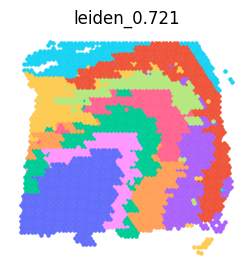

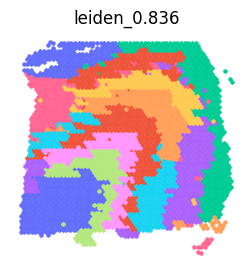

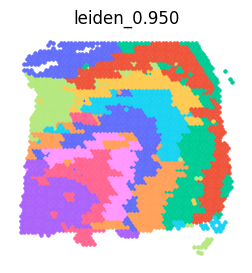

In [18]:

#Preprocess clusterings for each resolution
adata = phd_ms.tl.preprocess_leiden(INPUT_FILE,output_file=INPUT_FILE,emb=EMBEDDING,resolution=RESOLUTIONS,
                            res_keys=RES_KEYS,ground_truth=GROUND_TRUTH,neighbors=5,plots=True)


Constructing filtration...


100%|██████████| 7/7 [00:07<00:00,  1.02s/it]


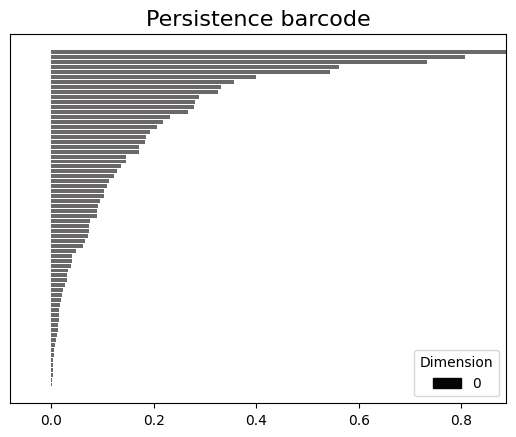

In [29]:
#Build cluster filtration
cluster_complex,clusterings= phd_ms.tl.cluster_filtration(adata,res_keys=RES_KEYS,index='containment')

#Plot persistence diagram
from gudhi import plot_persistence_barcode
from gudhi import SimplexTree
plot_persistence_barcode(cluster_complex.persistence(),colormap=((0.03,0.01,0.02),));
plt.savefig('/home/pbeamer/Documents/persistence_barcode.png',dpi=300)


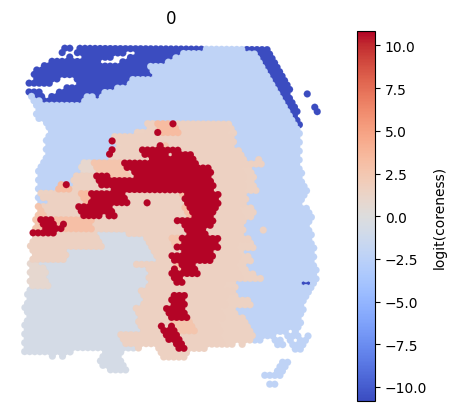

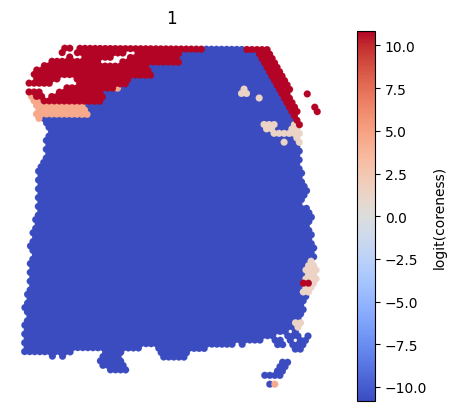

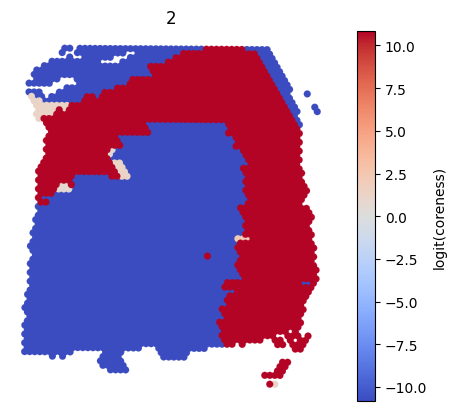

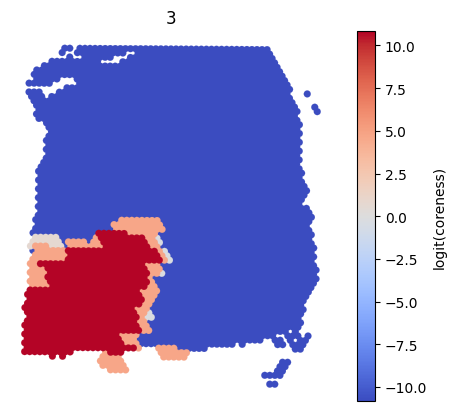

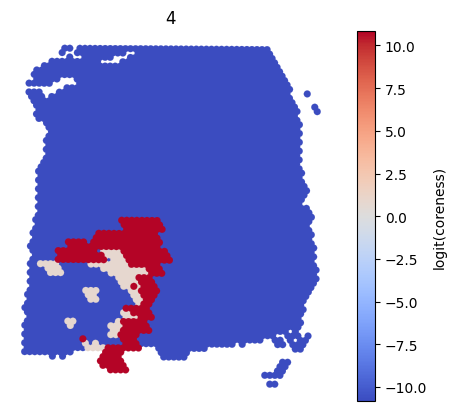

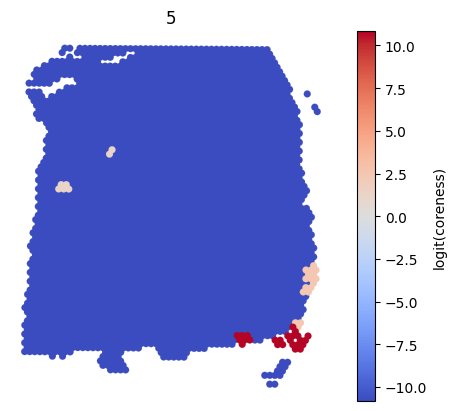

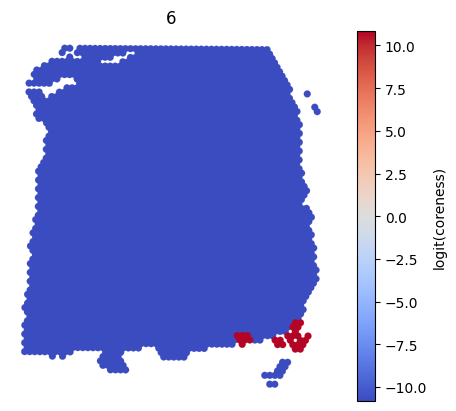

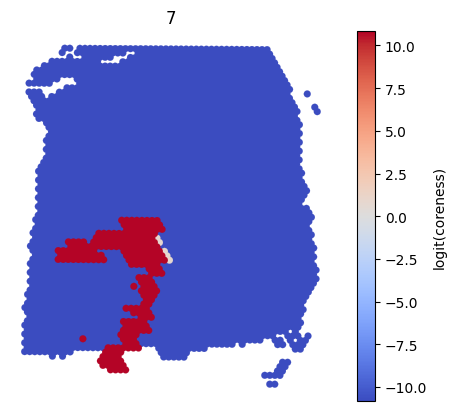

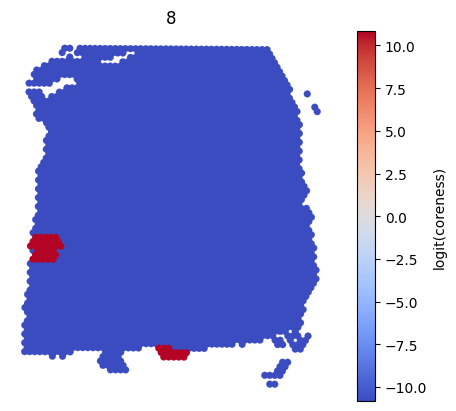

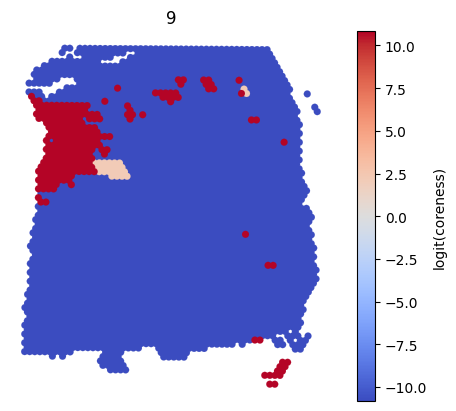

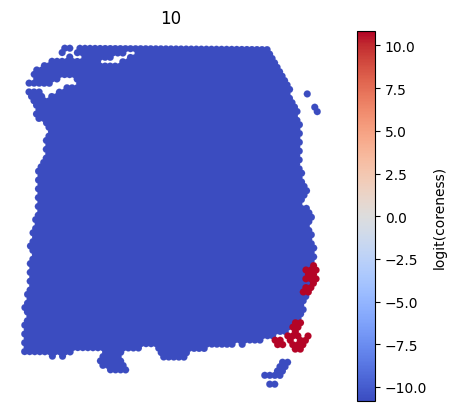

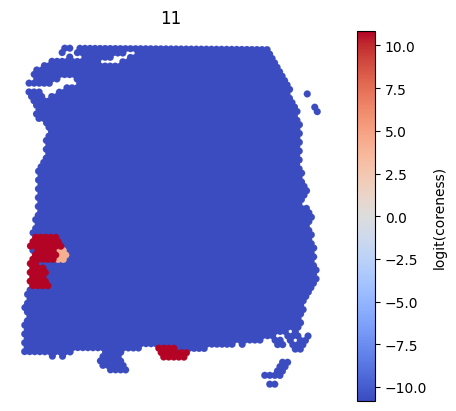

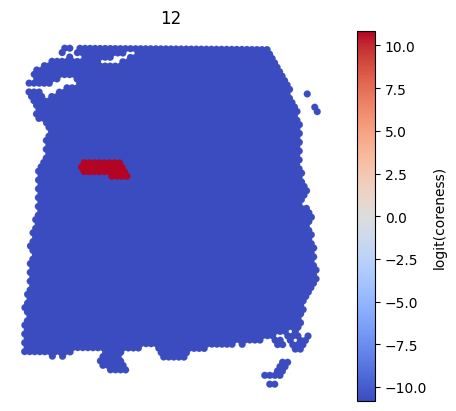

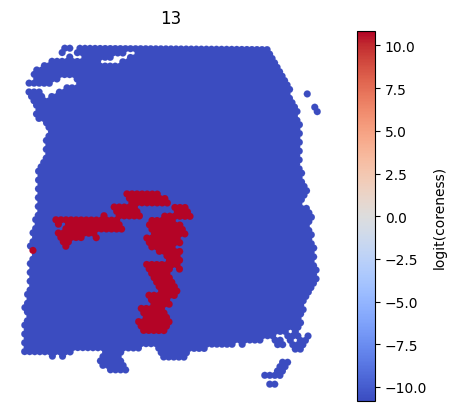

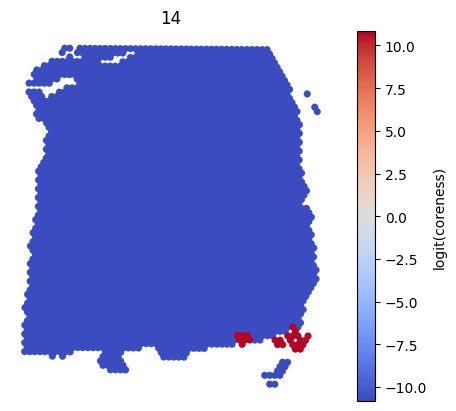

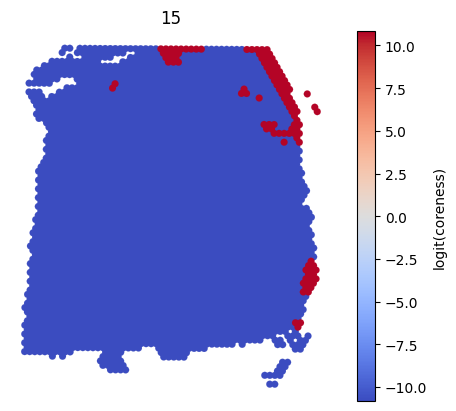

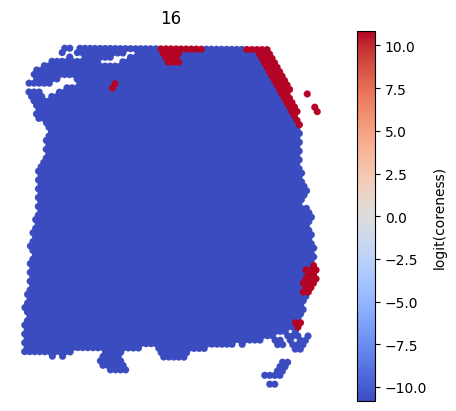

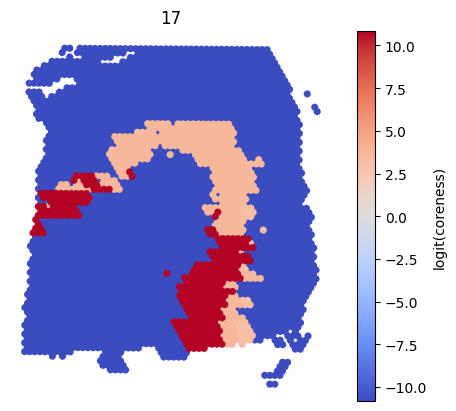

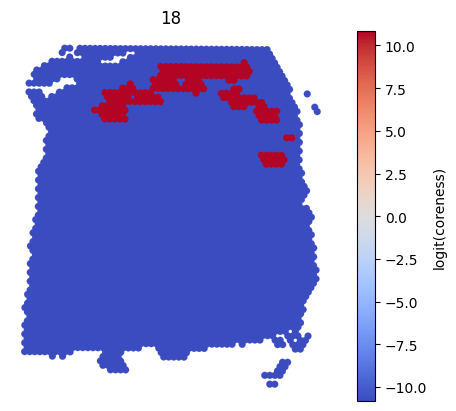

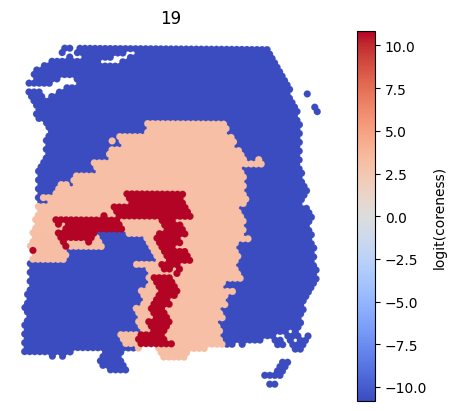

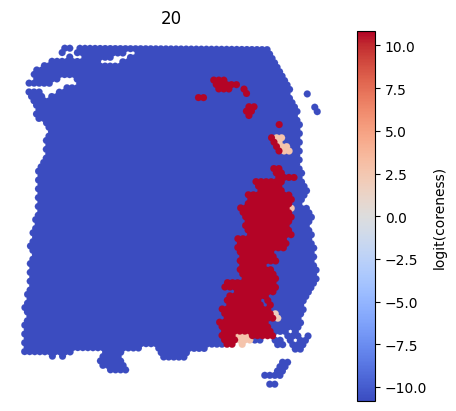

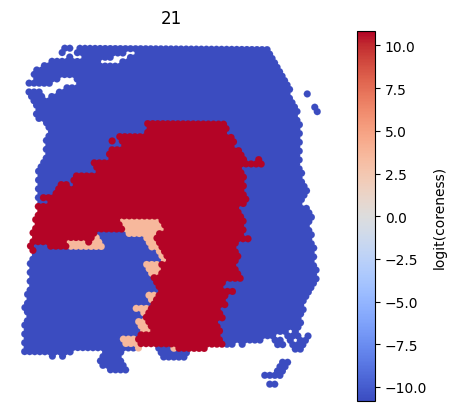

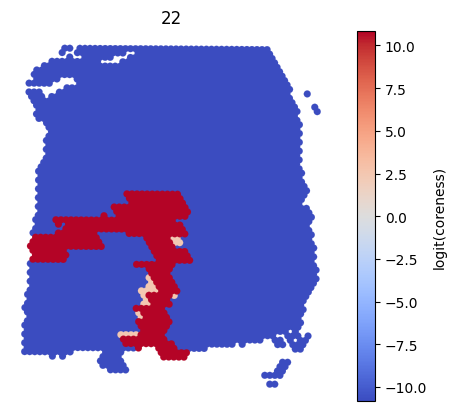

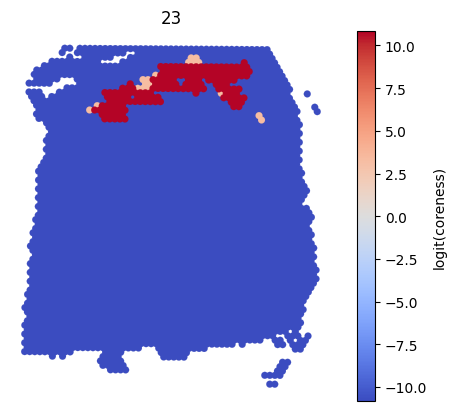

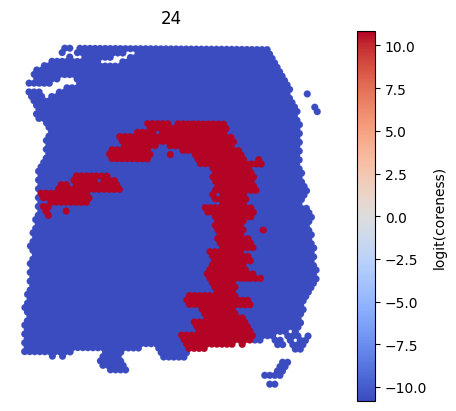

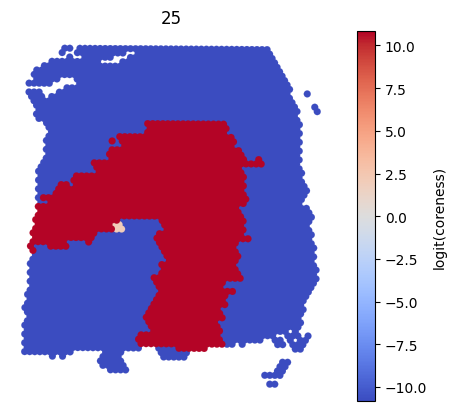

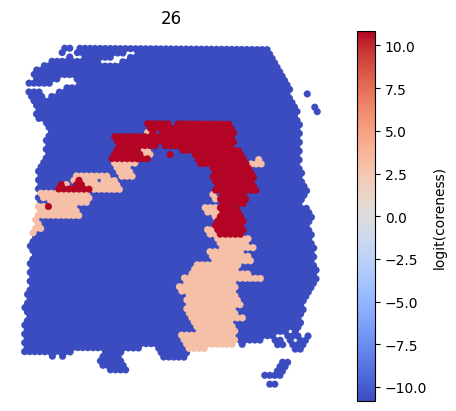

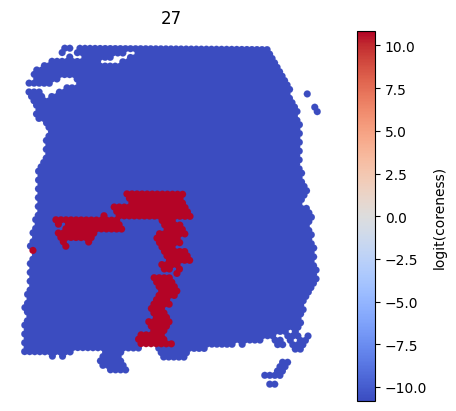

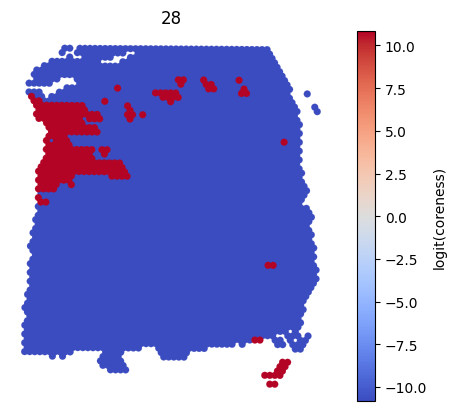

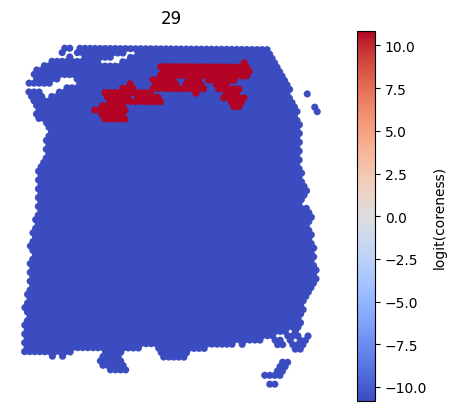

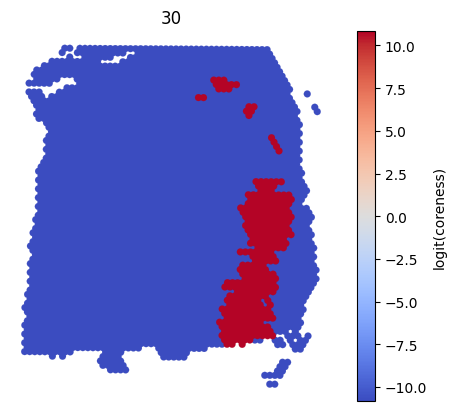

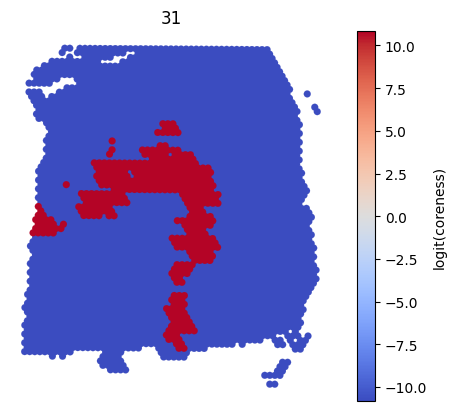

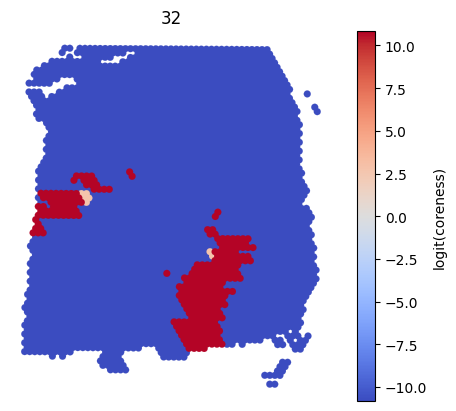

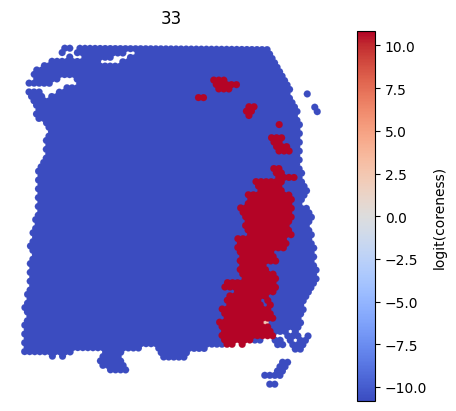

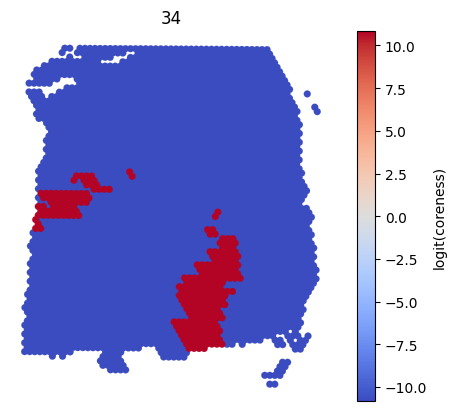

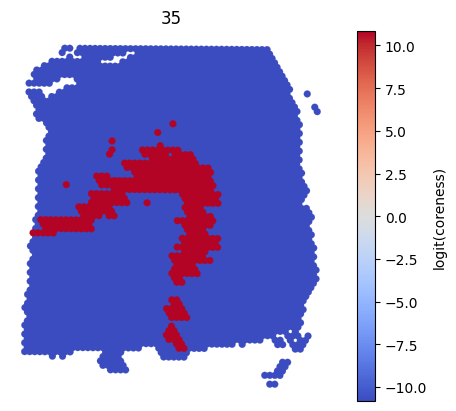

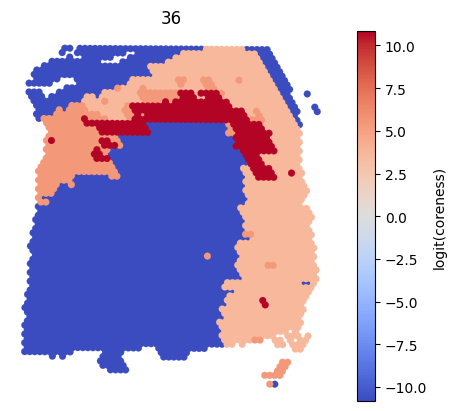

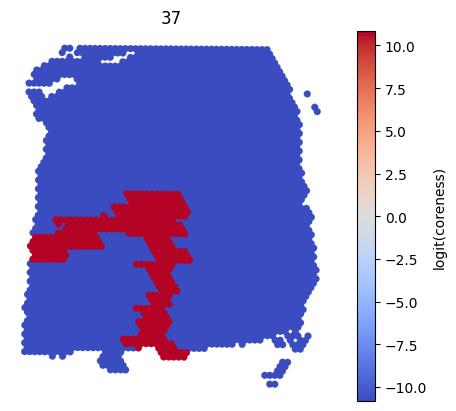

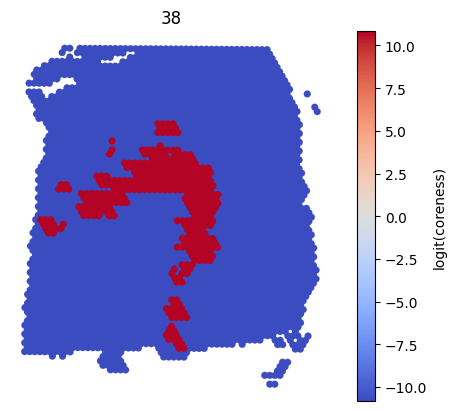

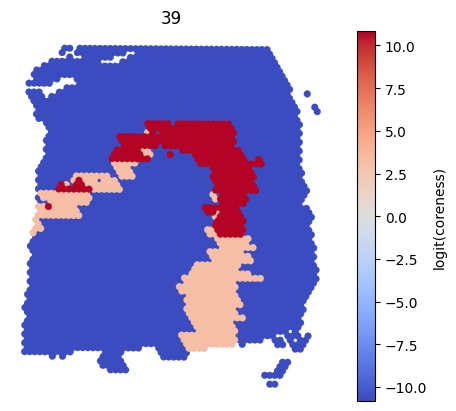

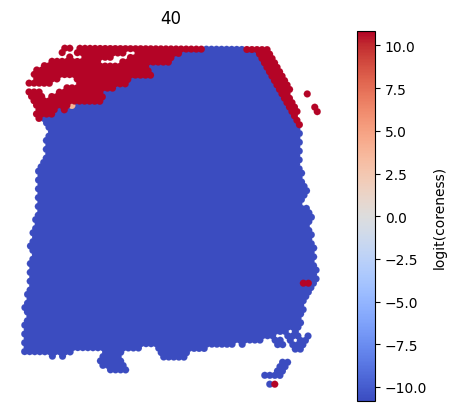

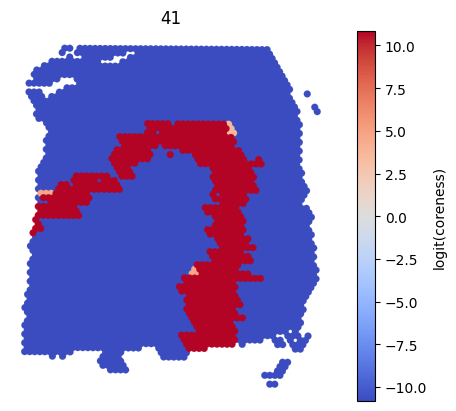

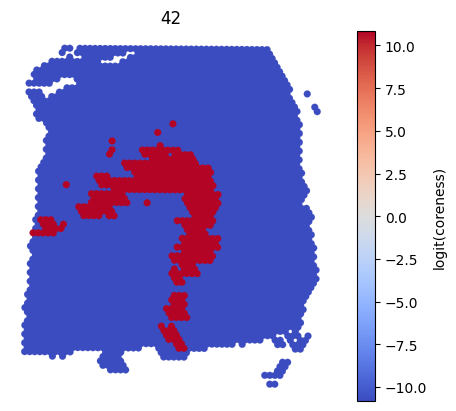

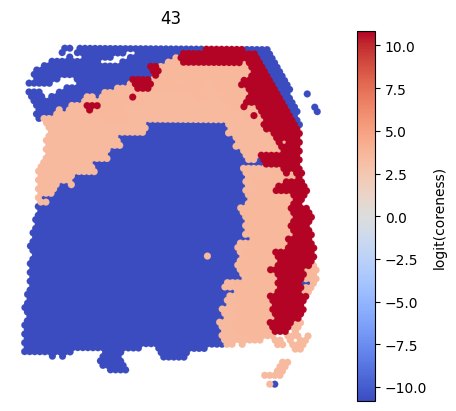

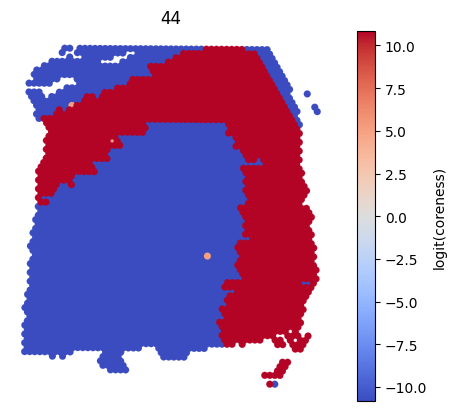

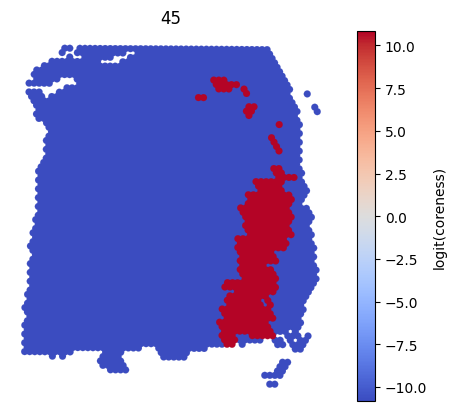

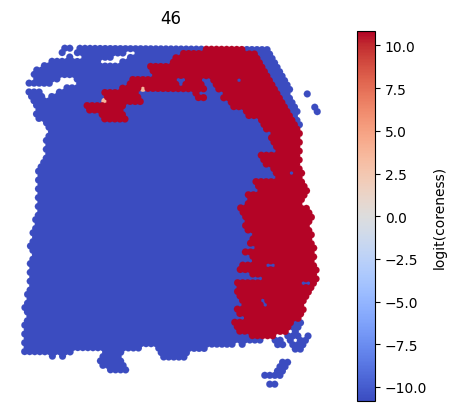

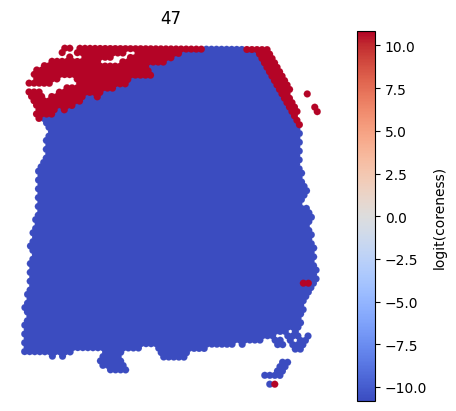

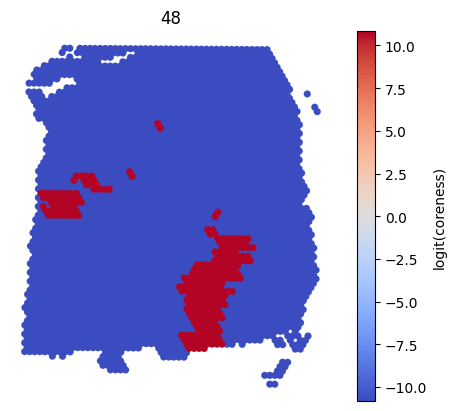

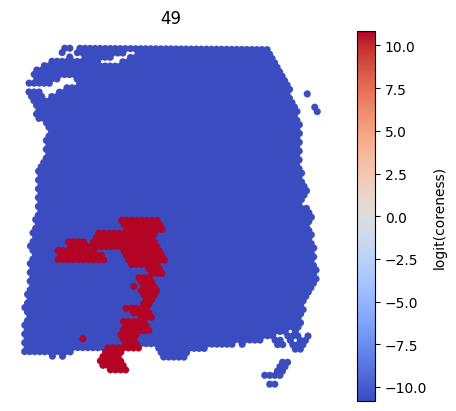

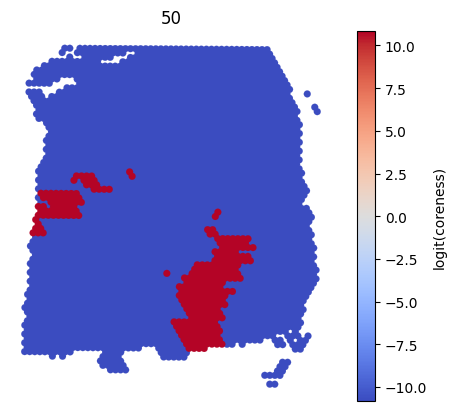

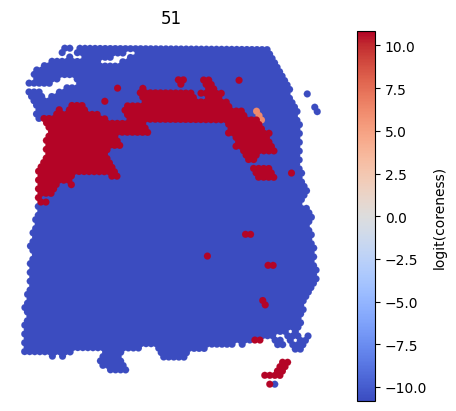

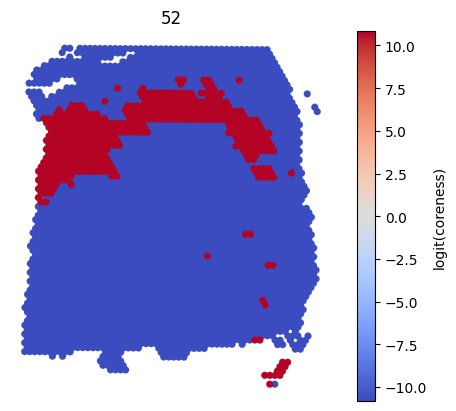

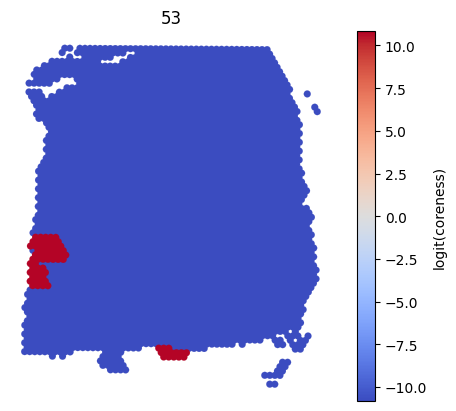

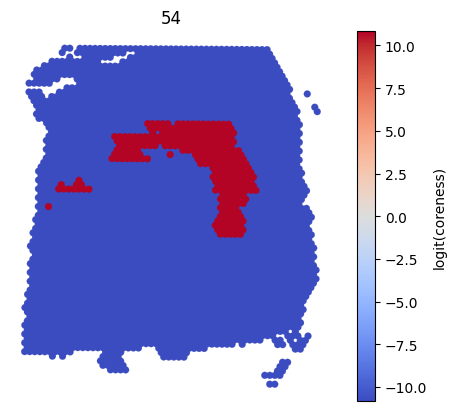

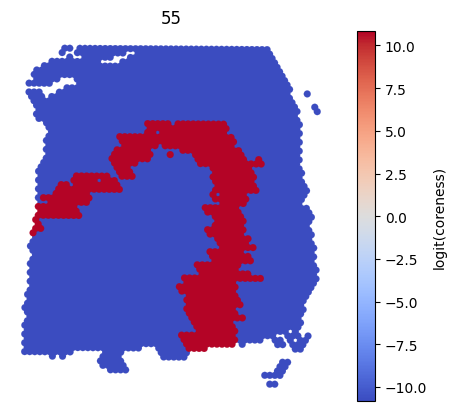

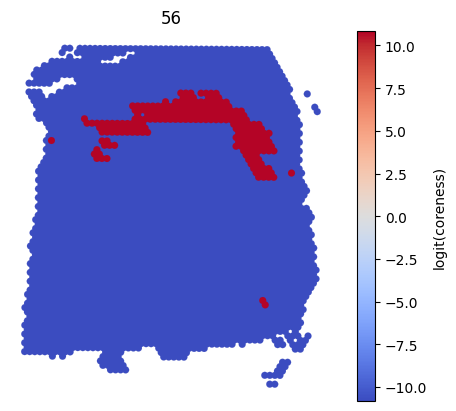

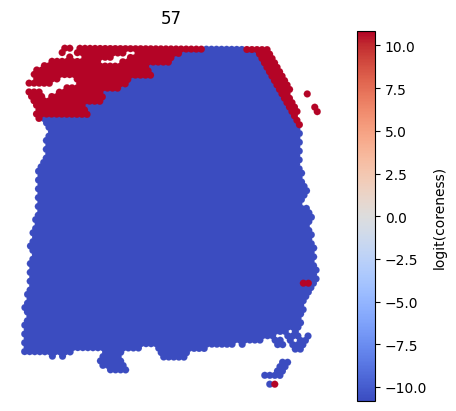

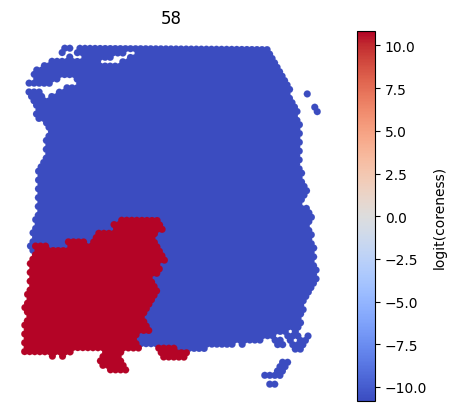

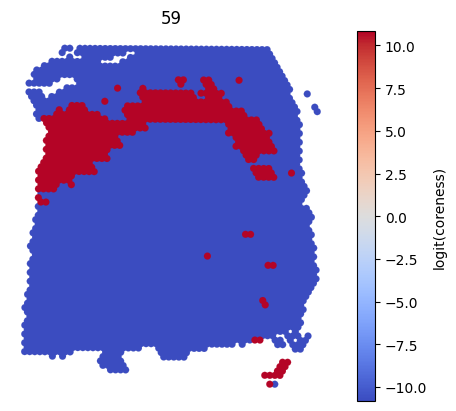

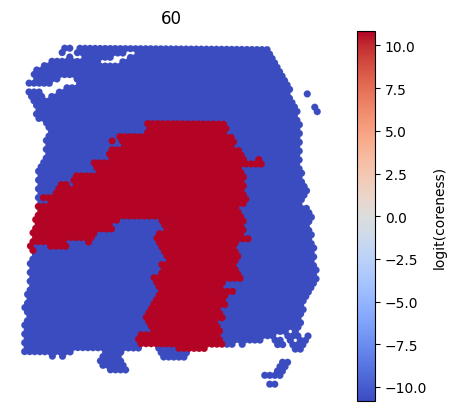

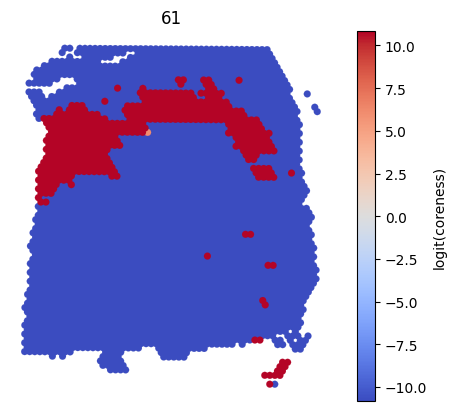

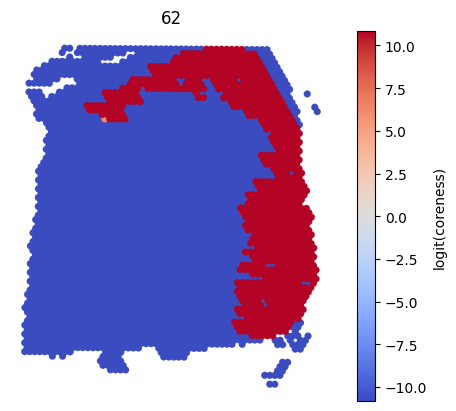

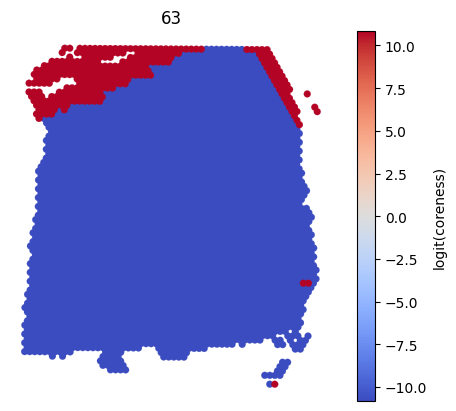

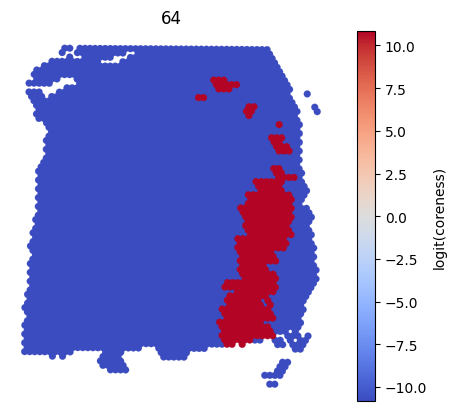

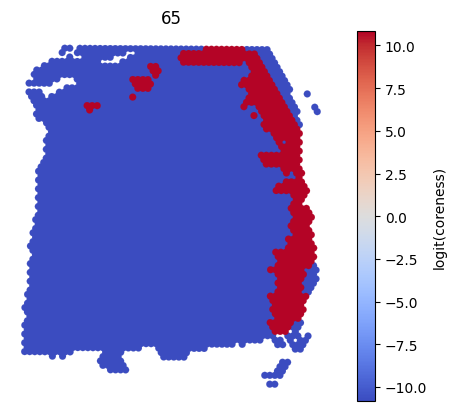

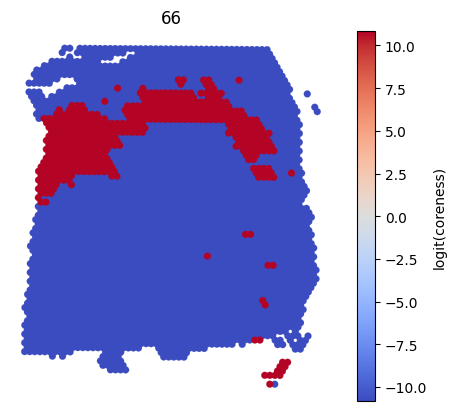

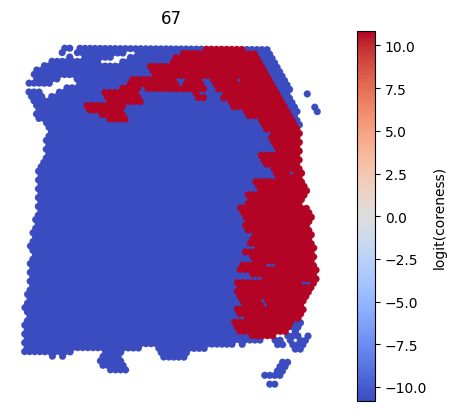

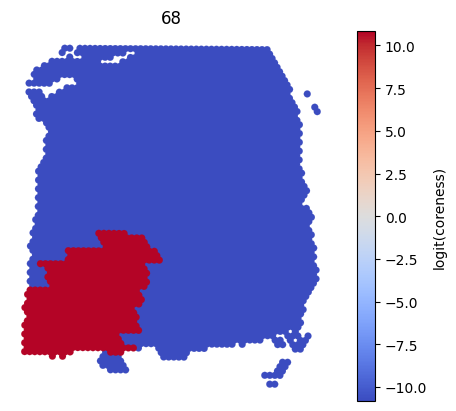

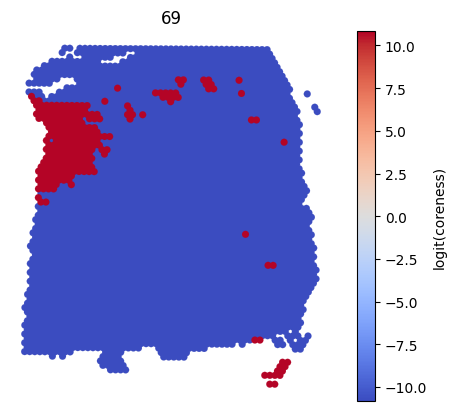

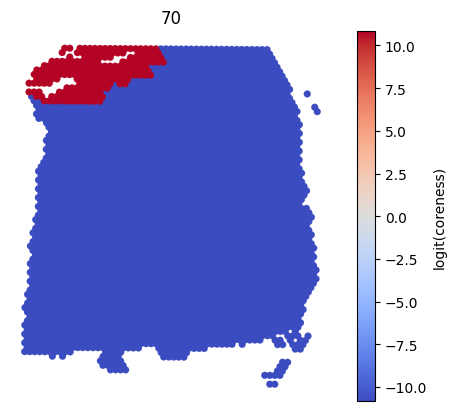

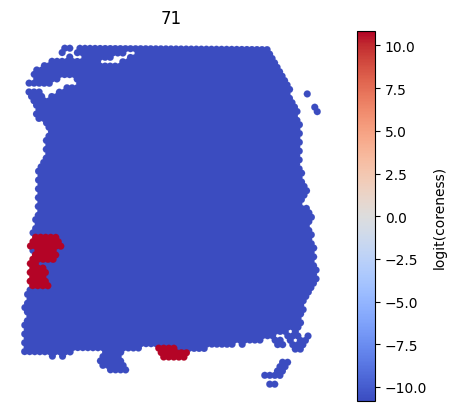

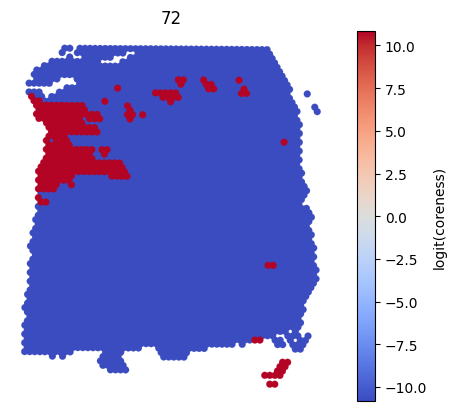

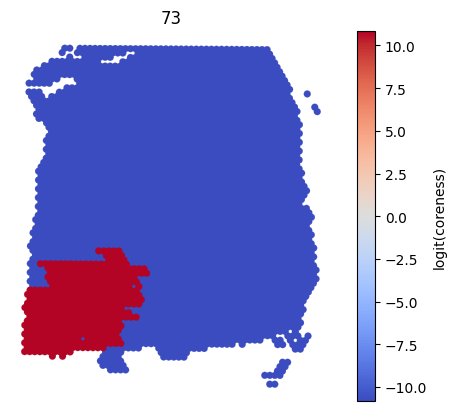

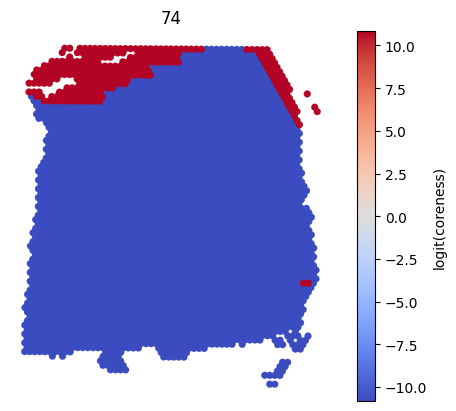

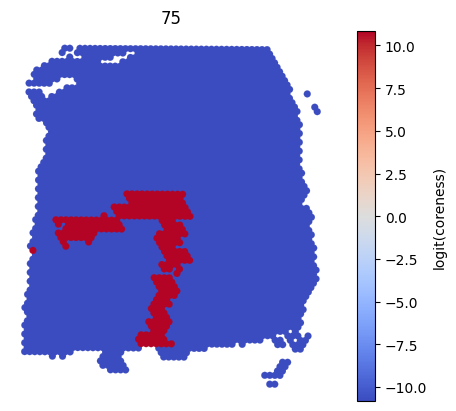

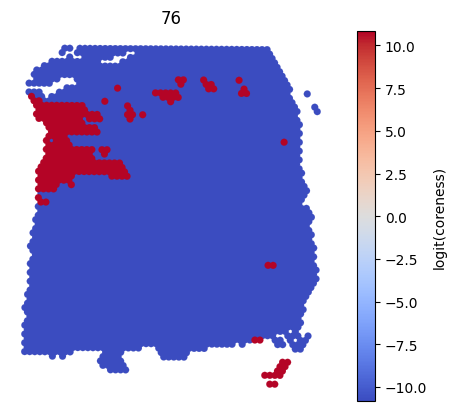

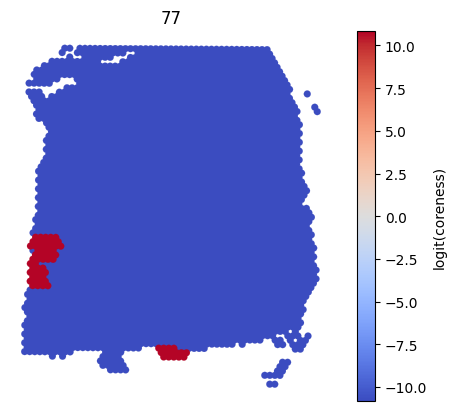

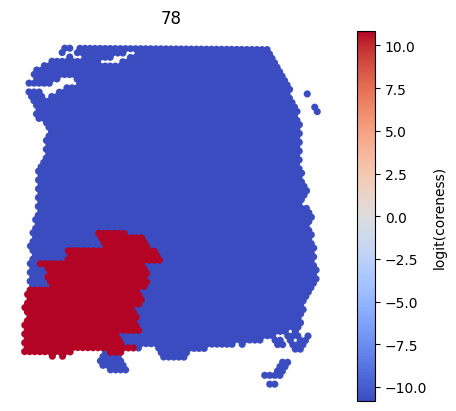

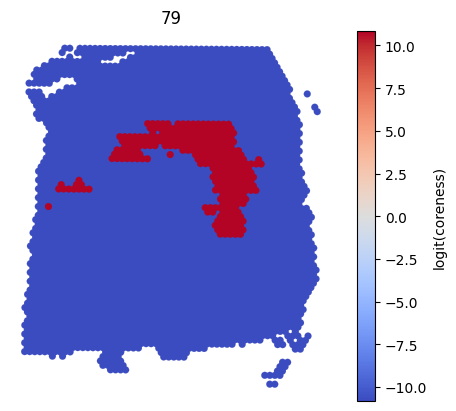

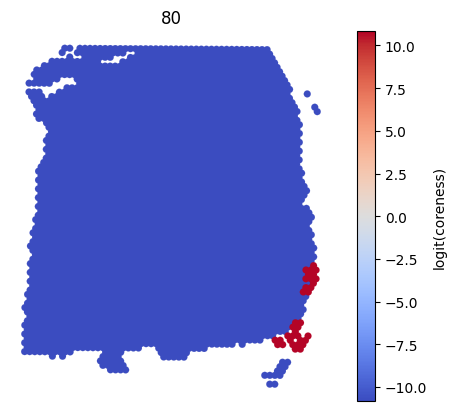

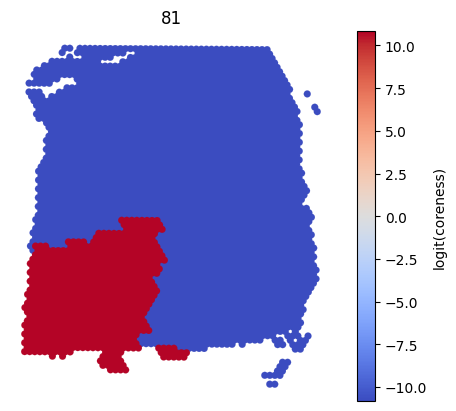

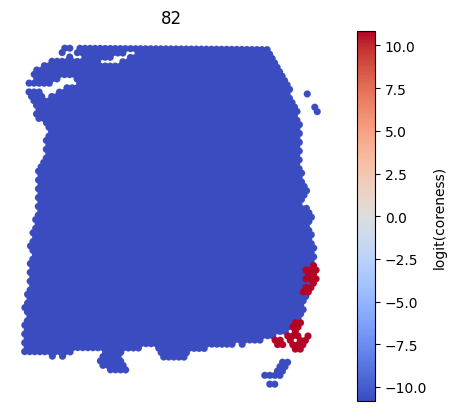

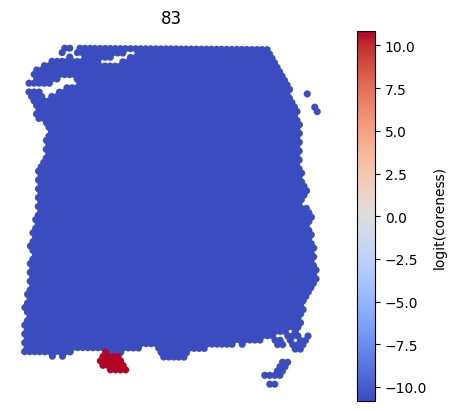

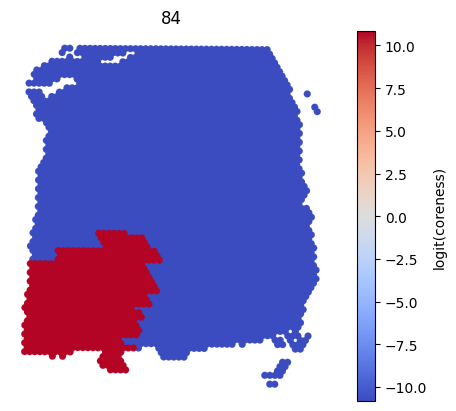

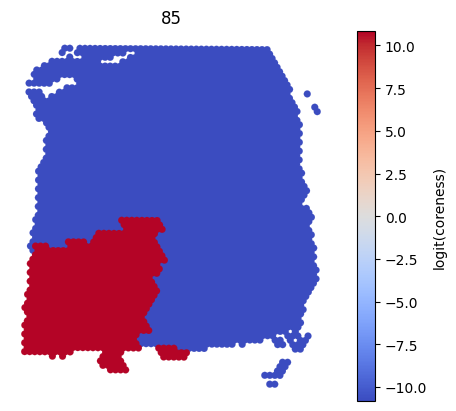

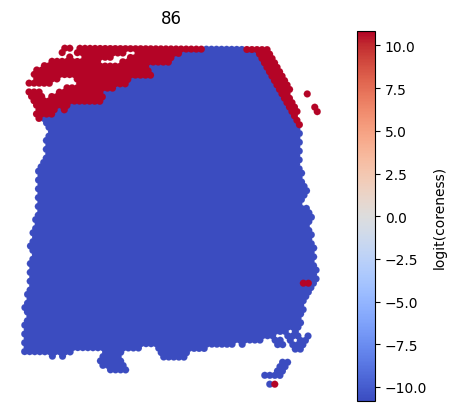

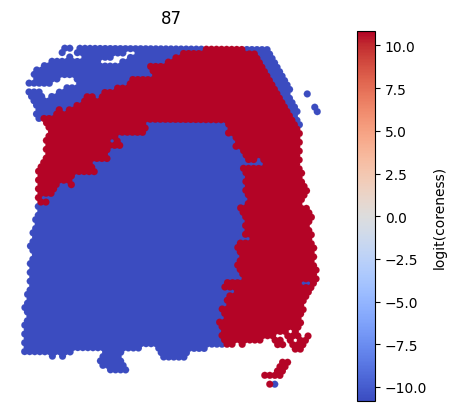

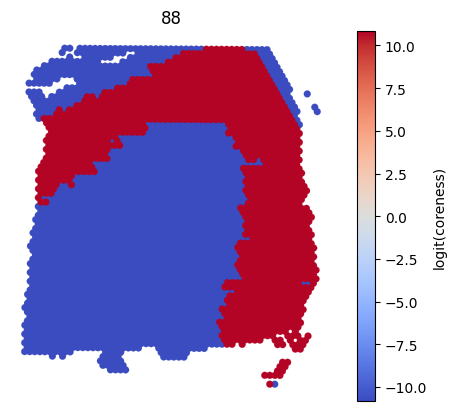

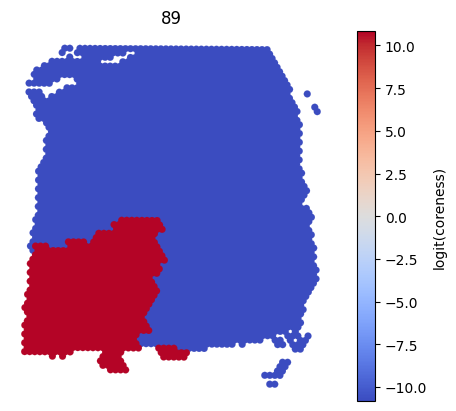

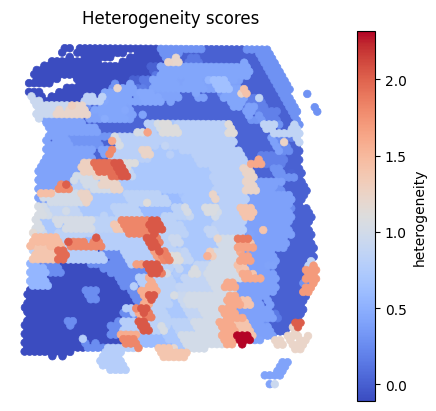

array([[0.09579121, 0.        , 1.        , ..., 1.        , 1.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.31952114, 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.82834983, 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.31952114, 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.09579121, 0.        , 1.        , ..., 1.        , 1.        ,
        0.        ]], shape=(3639, 90))

In [20]:

#map multiscale domains
phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=0,
                         order='persistence',plots='on')


In [21]:
#Compute benchmark metrics
adata.obsm['multiscale']= phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=0,filt=0,order='persistence',plots='off')
m = phd_ms.tl.ground_truth_benchmark(adata.obs[GROUND_TRUTH],adata.obsm['multiscale'],adata.obsm['spatial'],plots=True,conversion_factor=16.435,metrics=['wasserstein','nmi'])
print(m)

computing wasserstein distances...


 33%|███▎      | 209/630 [00:14<00:30, 13.97it/s]


KeyboardInterrupt: 

In [ ]:

#compare against single scale which best matches ground truth number of clusters
r = np.argmin(list(abs(len(adata.obs[GROUND_TRUTH].cat.categories.to_list()) - len(adata.obs[key].cat.categories.to_list())) for key in RES_KEYS))
r = RES_KEYS[r]
#Compute benchmarks for single scale clusters
m = phd_ms.tl.ground_truth_benchmark(adata.obs[GROUND_TRUTH],adata.obs[r],adata.obsm['spatial'],plots=False,conversion_factor=16.435,metrics=['wasserstein','nmi'])
print(f'{m}')

computing wasserstein distances...


100%|██████████| 70/70 [00:05<00:00, 13.36it/s]


optimizing normalized mutual information...


 56%|█████▋    | 28234/50000 [00:38<00:29, 733.74it/s]


KeyboardInterrupt: 